## Import libraries

In [1]:
import pandas as pd
import numpy as np
import openpyxl 

## Load dataset


In [2]:
data0=pd.read_csv('Airbnb_Open_Data.csv')
data0.head()

C:\Users\marwa\AppData\Local\Temp\ipykernel_13096\3813803547.py:1: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  data0=pd.read_csv('Airbnb_Open_Data.csv')


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [3]:
data0.shape

(102599, 26)

In [4]:
data0.info()

<class 'pandas.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  str    
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  str    
 4   host name                       102193 non-null  str    
 5   neighbourhood group             102570 non-null  str    
 6   neighbourhood                   102583 non-null  str    
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  str    
 10  country code                    102468 non-null  str    
 11  instant_bookable                102494 non-null  object 
 12  cancellation_policy        

## Preprocessing     

## 1. Handling missing values

In [5]:
data = data0.copy()

In [6]:
data.columns = data.columns.str.strip()

In [7]:
data.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            406
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365                     448
house_rules     

In [8]:
data.isnull().sum()/data.shape[0]*100

id                                 0.000000
NAME                               0.243667
host id                            0.000000
host_identity_verified             0.281679
host name                          0.395715
neighbourhood group                0.028265
neighbourhood                      0.015595
lat                                0.007797
long                               0.007797
country                            0.518524
country code                       0.127682
instant_bookable                   0.102340
cancellation_policy                0.074075
room type                          0.000000
Construction year                  0.208579
price                              0.240743
service fee                        0.266084
minimum nights                     0.398639
number of reviews                  0.178364
last review                       15.490404
reviews per month                 15.476759
review rate number                 0.317742
calculated host listings count  

In [9]:
data["host id"].nunique(), data["host name"].nunique()

(102057, 13190)

In [10]:
data["host id"].nunique(), data["id"].nunique()

(102057, 102058)

In [11]:
missing = pd.DataFrame({
    "Missing Count": data.isnull().sum(),
    "Missing %": round(data.isnull().mean()*100,2)
})

missing

,Missing Count,Missing %
id,0,0.00
NAME,250,0.24
host id,0,0.00
host_identity_verified,289,0.28
host name,406,0.40
neighbourhood group,29,0.03
neighbourhood,16,0.02
lat,8,0.01
long,8,0.01
country,532,0.52


In [12]:
data[data.duplicated()].head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
102058,35506831,Master Bedroom with private Bathroom & Balcony,55110690425,unconfirmed,UZeyir,Queens,Maspeth,40.74056,-73.90635,United States,...,$141,1.0,1.0,11/14/2021,0.27,3.0,1.0,339.0,NaN,NaN
102059,35507383,Cozy 2 br in sunny Fort Greene apt,80193772189,verified,Sally,Brooklyn,Fort Greene,40.68701,-73.97555,United States,...,$130,3.0,38.0,11/13/2021,0.27,3.0,1.0,0.0,NaN,NaN
102060,35507935,Duplex w/ Terrace @ Box House Hotel,72991962259,verified,The Box House Hotel,Brooklyn,Greenpoint,40.73756,-73.95350,United States,...,$181,3.0,10.0,11/13/2021,0.08,3.0,30.0,32.0,NaN,NaN
102061,35508488,"Cozy, clean Greenpoint room with yard access",74975156081,verified,Dawn,Brooklyn,Greenpoint,40.72516,-73.95004,United States,...,$118,30.0,38.0,11/13/2021,0.34,5.0,2.0,324.0,NaN,NaN
102062,35509040,2BR XL Loft: Cleaning CDC guidelines implemented,85844415221,unconfirmed,Vida,Brooklyn,Greenpoint,40.72732,-73.94185,United States,...,$71,30.0,13.0,11/13/2021,0.14,4.0,28.0,336.0,NaN,NaN


In [13]:
data.duplicated().sum()

np.int64(541)

In [14]:
data.drop_duplicates(inplace=True)

In [15]:
data["last review"] = pd.to_datetime(data["last review"])

In [16]:
data["price"] = (
    data["price"]
      .replace('[\$,]', '', regex=True)
      .astype(float)
)
data["service fee"] = (
    data["service fee"]
      .replace('[\$,]', '', regex=True)
      .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:8: SyntaxWarning: invalid escape sequence '\$'
C:\Users\marwa\AppData\Local\Temp\ipykernel_13096\3425462995.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)
C:\Users\marwa\AppData\Local\Temp\ipykernel_13096\3425462995.py:8: SyntaxWarning: invalid escape sequence '\$'
  .replace('[\$,]', '', regex=True)


In [17]:
data[['price', 'service fee']].describe()

,price,service fee
count,101811.000000,101785.000000
mean,625.355580,125.039249
std,331.672649,66.325905
min,50.000000,10.000000
25%,340.000000,68.000000
50%,625.000000,125.000000
75%,913.000000,183.000000
max,1200.000000,240.000000


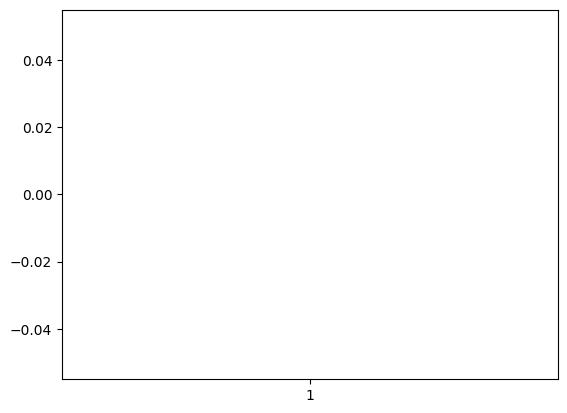

In [18]:
import matplotlib.pyplot as plt

plt.boxplot([data['price']])
plt.show()

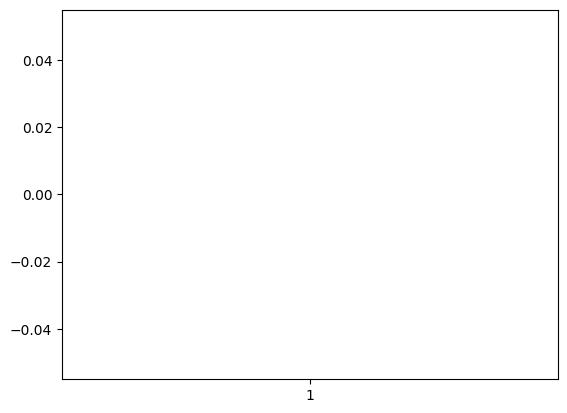

In [19]:

plt.boxplot([data['service fee']])
plt.show()

In [20]:
# Calculate IQR for 'price'
Q1_price = data['price'].quantile(0.25)
Q3_price = data['price'].quantile(0.75)
IQR_price = Q3_price - Q1_price

lower_price = Q1_price - 1.5 * IQR_price
upper_price = Q3_price + 1.5 * IQR_price

# Calculate IQR for 'service fee'
Q1_fee = data['service fee'].quantile(0.25)
Q3_fee = data['service fee'].quantile(0.75)
IQR_fee = Q3_fee - Q1_fee

lower_fee = Q1_fee - 1.5 * IQR_fee
upper_fee = Q3_fee + 1.5 * IQR_fee

# Detect outliers
price_outliers = data[
    (data['price'] < lower_price) |
    (data['price'] > upper_price)
]

service_fee_outliers = data[
    (data['service fee'] < lower_fee) |
    (data['service fee'] > upper_fee)
]

print("Price Outliers:", len(price_outliers))
print("Service Fee Outliers:", len(service_fee_outliers))

Price Outliers: 0
Service Fee Outliers: 0


# comment
using the IQR method, so no outlier treatment was required.


In [21]:
data.drop(columns=["license"], inplace=True)

# Comment
Normalization: house_rules moved to house_rules_table (id = Foreign Key).

Runs once on the original column.

In [22]:
data["house_rules"] = data["house_rules"].replace("#NAME?", np.nan)
house_rules_table = data.loc[data["house_rules"].notna(), ["id", "house_rules"]].reset_index(drop=True)
data.drop(columns=["house_rules"], inplace=True)

In [23]:
data.isnull().sum()

id                                    0
NAME                                250
host id                               0
host_identity_verified              289
host name                           404
neighbourhood group                  29
neighbourhood                        16
lat                                   8
long                                  8
country                             532
country code                        131
instant_bookable                    105
cancellation_policy                  76
room type                             0
Construction year                   214
price                               247
service fee                         273
minimum nights                      400
number of reviews                   183
last review                       15832
reviews per month                 15818
review rate number                  319
calculated host listings count      319
availability 365                    448
dtype: int64

In [24]:
data["country"].value_counts(dropna=False)

country
United States    101526
NaN                 532
Name: count, dtype: int64

# comment
 Check the number of unique classes in the column

In [25]:
data["country"] = data["country"].fillna("United States")

In [26]:
data["country"].isnull().sum()

np.int64(0)

In [27]:
data["country code"].value_counts(dropna=False)

country code
US     101927
NaN       131
Name: count, dtype: int64

In [28]:
data["country code"] = data["country code"].fillna("US")

In [29]:
data["host_identity_verified"].value_counts(dropna=False)

host_identity_verified
unconfirmed    50944
verified       50825
NaN              289
Name: count, dtype: int64

# Comment
no missing values left, and class ratio still (50/50)

In [30]:
np.random.seed(0)
probs = data["host_identity_verified"].value_counts(normalize=True)
missing_mask = data["host_identity_verified"].isna()
data.loc[missing_mask, "host_identity_verified"] = np.random.choice(
    probs.index, size=missing_mask.sum(), p=probs.values
)

In [31]:
host_map = data.dropna(subset=['host name']) \
               .drop_duplicates('host id') \
               .set_index('host id')['host name']

mask = data['host name'].isna()

data.loc[mask, 'host name'] = data.loc[mask, 'host id'].map(host_map)

In [32]:
data['host name'].isnull().sum()

np.int64(404)

In [33]:
data['host name'] = data['host name'].fillna('Unknown Host')

In [34]:
name_map = (
    data.dropna(subset=['NAME'])
        .drop_duplicates('host id')
        .set_index('host id')['NAME']
)


mask = data['NAME'].isna()


data.loc[mask, 'NAME'] = data.loc[mask, 'host id'].map(name_map)

In [35]:
name_map_location = (
    data.dropna(subset=['NAME'])
        .drop_duplicates(['lat','long'])
        .set_index(['lat','long'])['NAME']
)


mask = data['NAME'].isna()

data.loc[mask,'NAME'] = (
    data.loc[mask]
    .set_index(['lat','long'])
    .index.map(name_map_location)
)

In [36]:
data['NAME'].isnull().sum()

np.int64(152)

In [37]:
data['NAME'] = data['NAME'].fillna('Unknown')

In [38]:
data["neighbourhood"].value_counts().head()

neighbourhood
Bedford-Stuyvesant    7898
Williamsburg          7732
Harlem                5441
Bushwick              4956
Hell's Kitchen        3949
Name: count, dtype: int64

In [39]:
data["neighbourhood group"].value_counts()

neighbourhood group
Manhattan        43557
Brooklyn         41630
Queens           13197
Bronx             2694
Staten Island      949
brookln              1
manhatan             1
Name: count, dtype: int64

In [40]:
data["neighbourhood group"] = data["neighbourhood group"].replace({
    "brookln": "Brooklyn",
    "manhatan": "Manhattan"
})

In [41]:
house_rules_table["house_rules"] = (
    house_rules_table["house_rules"]
    .str.lower()
)

In [42]:
house_rules_table["No Smoking"] = (
    house_rules_table["house_rules"]
    .str.contains("no smoking|smoking not allowed|smoking is prohibited|non-smoking", case=False, regex=True, na=False)
)

In [43]:
house_rules_table["No Pets"] = (
    house_rules_table["house_rules"]
    .str.contains("no pet|pets not allowed|not pet friendly|no animals", case=False, regex=True, na=False)
)

In [44]:
house_rules_table["No Parties"] = (
    house_rules_table["house_rules"]
    .str.contains("no party|no parties", regex=True, na=False)
)

In [45]:
house_rules_table["Quiet Hours"] = (
    house_rules_table["house_rules"]
    .str.contains("quiet", na=False)
)

In [46]:
house_rules_table.head()

,id,house_rules,No Smoking,No Pets,No Parties,Quiet Hours
0,1001254,clean up and treat the home the way you'd like...,True,False,False,False
1,1002102,pet friendly but please confirm with me if the...,False,False,False,True
2,1002403,"i encourage you to use my kitchen, cooking and...",True,False,False,False
3,1003689,"please no smoking in the house, porch or on th...",True,False,False,True
4,1004098,"no smoking, please, and no drugs.",True,False,False,False


In [47]:
house_rules_table[
    [
        "No Smoking",
        "No Pets",
        "No Parties",
        "Quiet Hours"
    ]
].sum()

No Smoking     25586
No Pets        12039
No Parties      7166
Quiet Hours     8581
dtype: int64

# Comment

 Impute missing neighbourhood/neighbourhood group using their relationship

In [48]:
np.random.seed(0)

nbhd_to_group = data.dropna(subset=["neighbourhood", "neighbourhood group"]).drop_duplicates("neighbourhood").set_index("neighbourhood")["neighbourhood group"]
mask_group = data["neighbourhood group"].isna()
data.loc[mask_group, "neighbourhood group"] = data.loc[mask_group, "neighbourhood"].map(nbhd_to_group)

mask_nbhd = data["neighbourhood"].isna()
for grp in data.loc[mask_nbhd, "neighbourhood group"].dropna().unique():
    grp_mask = mask_nbhd & (data["neighbourhood group"] == grp)
    probs = data.loc[data["neighbourhood group"] == grp, "neighbourhood"].value_counts(normalize=True)
    data.loc[grp_mask, "neighbourhood"] = np.random.choice(probs.index, size=grp_mask.sum(), p=probs.values)

In [49]:
data[data["minimum nights"] <= 0]

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365
176,1098541,BROOKLYN VICTORIAN STYLE SUITE.....,83631499592,unconfirmed,Frederick,Brooklyn,Fort Greene,40.69098,-73.97113,United States,...,2008.0,1155.0,231.0,-10.0,213.0,2019-06-24,2.00,5.0,2.0,19.0
352,1195746,"Beautiful, Bright’s, Warm & Spacious 1.5BR Apt",2227683633,unconfirmed,Grant,Brooklyn,Crown Heights,40.67174,-73.95663,United States,...,2009.0,73.0,15.0,-5.0,104.0,2019-06-21,1.04,5.0,1.0,31.0
398,1221151,SUPER BIG AND COZY PRIVATE BEDROOM,50336791874,verified,Tucker,Brooklyn,Kensington,40.64302,-73.97255,United States,...,2015.0,779.0,156.0,-1.0,82.0,2019-05-19,0.94,2.0,2.0,131.0
421,1233854,Charming Nolita Apartment!!,7389895192,verified,Belinda,Manhattan,Nolita,40.72094,-73.99706,United States,...,2008.0,874.0,175.0,-10.0,68.0,2019-06-10,0.69,5.0,1.0,13.0
441,1244900,Cozy apartment in a brownstone,81186886194,verified,Adelaide,Manhattan,Harlem,40.80497,-73.95016,United States,...,2021.0,920.0,184.0,-12.0,203.0,2019-07-06,2.14,5.0,3.0,77.0
478,1265335,Charming upper west side apartment,89878315253,unconfirmed,Alen,Manhattan,Upper West Side,40.77886,-73.98042,United States,...,2022.0,410.0,82.0,-2.0,129.0,2019-06-07,1.33,2.0,1.0,381.0
525,1291294,Chateau Style Brooklyn Loft for Singles or Cou...,2631536622,verified,Carlos,Brooklyn,Bedford-Stuyvesant,40.68967,-73.95445,United States,...,2022.0,413.0,83.0,-3.0,42.0,2019-05-18,0.44,5.0,1.0,292.0
42446,24444262,"Cozy room in bright, spacious apartment",84040511136,verified,Steven,Bronx,Hunts Point,40.81731,-73.89052,United States,...,2003.0,1200.0,240.0,-1223.0,0.0,NaT,NaN,2.0,4.0,341.0
42500,24474086,2bd BOUTIQUE Apartament in the heart of MANHA...,2679070022,unconfirmed,Tom,Manhattan,Hell's Kitchen,40.76694,-73.98773,United States,...,2009.0,711.0,142.0,-365.0,13.0,2019-07-07,5.91,4.0,4.0,0.0
42538,24495073,Newly Renovated Garden Apartment,98469733112,verified,Margie,Brooklyn,Bedford-Stuyvesant,40.68470,-73.94350,United States,...,2022.0,85.0,17.0,-200.0,3.0,2019-04-23,1.06,2.0,1.0,157.0


In [50]:
data = data[
    (data["minimum nights"] > 0) &
    (data["minimum nights"] <= 365)
]

data = data[
    (data["availability 365"] >= 0) &
    (data["availability 365"] <= 365)
]



# comment
 Remove rows with invalid values in 'minimum nights'

 Keep only listings where minimum nights is between 1 and 365

 Remove rows with invalid values in 'availability 365'

 Keep only values within the valid range (0–365 days)
 

In [51]:
data[["availability 365", "minimum nights"]].isnull().sum()

availability 365    0
minimum nights      0
dtype: int64

# Comment
Fill remaining missing latitude and longitude
using the mean coordinates of each neighbourhood.
This preserves the geographical consistency of the listings.

In [52]:
lat_map = (
    data.dropna(subset=['lat'])
        .drop_duplicates('host id')
        .set_index('host id')['lat']
)

mask = data['lat'].isna()

data.loc[mask, 'lat'] = data.loc[mask, 'host id'].map(lat_map)
long_map = (
    data.dropna(subset=['long'])
        .drop_duplicates('host id')
        .set_index('host id')['long']
)

mask = data['long'].isna()

data.loc[mask, 'long'] = data.loc[mask, 'host id'].map(long_map)

In [53]:
print(data['lat'].isna().sum())
print(data['long'].isna().sum())

8
8


In [54]:
lat_mean = data.groupby("neighbourhood")["lat"].mean()

mask = data["lat"].isna()

data.loc[mask,"lat"] = data.loc[mask,"neighbourhood"].map(lat_mean)

In [55]:
long_mean = data.groupby("neighbourhood")["long"].mean()

mask = data["long"].isna()

data.loc[mask,"long"] = data.loc[mask,"neighbourhood"].map(long_mean)

In [56]:
print(data['lat'].isna().sum())
print(data['long'].isna().sum())

0
0


In [57]:
data["instant_bookable"].isnull().sum()


np.int64(74)

In [58]:
probs = data["instant_bookable"].value_counts(normalize=True)

mask = data["instant_bookable"].isna()

data.loc[mask, "instant_bookable"] = np.random.choice(
    probs.index,
    size=mask.sum(),
    p=probs.values
)

In [59]:
data['cancellation_policy'].value_counts()

cancellation_policy
moderate    32768
strict      32610
flexible    32590
Name: count, dtype: int64

In [60]:
missing_count = data['cancellation_policy'].isna().sum()

distribution = data['cancellation_policy'].value_counts(normalize=True)

classes = distribution.index

random_values = np.random.choice(
    classes,
    size=missing_count,
    p=distribution.values
)

data.loc[data['cancellation_policy'].isna(), 'cancellation_policy'] = random_values

In [61]:
data["cancellation_policy"].isnull().sum()

np.int64(0)

In [62]:
data["cancellation_policy"].isnull().sum()

np.int64(0)

In [63]:
data = data.dropna(subset=["price"])
data = data.dropna(subset=["service fee"])

In [64]:
data[["price", "service fee"]].isnull().sum()

price          0
service fee    0
dtype: int64

In [65]:
data.isnull().sum()

id                                    0
NAME                                  0
host id                               0
host_identity_verified                0
host name                             0
neighbourhood group                   0
neighbourhood                         0
lat                                   0
long                                  0
country                               0
country code                          0
instant_bookable                      0
cancellation_policy                   0
room type                             0
Construction year                   156
price                                 0
service fee                           0
minimum nights                        0
number of reviews                   126
last review                       14854
reviews per month                 14856
review rate number                  277
calculated host listings count      290
availability 365                      0
dtype: int64

In [66]:
data["Construction year"] = data["Construction year"].fillna(
    data["Construction year"].median()
)

In [67]:
host_count = data['host id'].value_counts()

host_listing_count = data['host id'].value_counts()

data['calculated host listings count'] = data['host id'].map(host_listing_count)

In [68]:
data['calculated host listings count'].isna().sum()

np.int64(0)

In [69]:
data[
    (data['review rate number'] < 1) |
    (data['review rate number'] > 5)
]

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365


In [70]:
data['review rate number'].describe()

count    97282.000000
mean         3.286990
std          1.279403
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: review rate number, dtype: float64

In [71]:
data[data['reviews per month'] < 0]

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,Construction year,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365


In [72]:
data['reviews per month'].describe()

count    82703.000000
mean         1.391288
std          1.758143
min          0.010000
25%          0.230000
50%          0.760000
75%          2.030000
max         90.000000
Name: reviews per month, dtype: float64

In [73]:
print(data['last review'].min())
print(data['last review'].max())

2012-07-11 00:00:00
2058-06-16 00:00:00


In [74]:
data[data['last review'] > pd.Timestamp.today()].shape

(2, 24)

In [75]:
data.loc[
    data['last review'] > pd.Timestamp.today(),
    'last review'
] = pd.NaT

In [76]:
data[
    ['number of reviews', 'last review', 'reviews per month', 'review rate number']
].isna().value_counts()

number of reviews  last review  reviews per month  review rate number
False              False        False              False                 82394
                   True         True               False                 14745
                   False        False              True                    243
True               True         True               False                    69
                   False        False              False                    57
False              True         True               True                     33
                   False        True               False                     9
                   True         False              False                     8
                                                   True                      1
Name: count, dtype: int64

In [77]:
data['review_status'] = np.where(
    data['last review'].isna() &
    data['reviews per month'].isna(),
    'No Reviews',
    'Has Reviews'
)

# comment
Created a new feature (review_status) based on the last review and reviews per month columnsbecause both columns showed a strong missing-value relationship and represented the presence or absence of review activity

# Comment

 Impute missing review-related columns based on relationships between them (no rows dropped)

In [78]:
np.random.seed(0)

mask_no_reviews = data["last review"].isna() & data["reviews per month"].isna()
data.loc[mask_no_reviews, "reviews per month"] = data.loc[mask_no_reviews, "reviews per month"].fillna(0)
data.loc[mask_no_reviews, "number of reviews"] = data.loc[mask_no_reviews, "number of reviews"].fillna(0)

mask_remaining_num = data["number of reviews"].isna()
median_reviews = data.loc[data["reviews per month"] > 0, "number of reviews"].median()
data.loc[mask_remaining_num, "number of reviews"] = median_reviews

mask_remaining_rpm = data["reviews per month"].isna()
median_rpm = data.loc[data["number of reviews"] > 0, "reviews per month"].median()
data.loc[mask_remaining_rpm, "reviews per month"] = median_rpm

probs = data["review rate number"].value_counts(normalize=True)
mask_rate = data["review rate number"].isna()
data.loc[mask_rate, "review rate number"] = np.random.choice(probs.index, size=mask_rate.sum(), p=probs.values)

In [79]:
house_rules_table["id"].duplicated().sum()

np.int64(0)

In [80]:
data.isnull().sum()

id                                    0
NAME                                  0
host id                               0
host_identity_verified                0
host name                             0
neighbourhood group                   0
neighbourhood                         0
lat                                   0
long                                  0
country                               0
country code                          0
instant_bookable                      0
cancellation_policy                   0
room type                             0
Construction year                     0
price                                 0
service fee                           0
minimum nights                        0
number of reviews                     0
last review                       14856
reviews per month                     0
review rate number                    0
calculated host listings count        0
availability 365                      0
review_status                         0


In [81]:
data["id"].duplicated().sum()

np.int64(0)

In [82]:
data["id"].dtype

dtype('int64')

In [83]:
data.info()

<class 'pandas.DataFrame'>
Index: 97559 entries, 0 to 102044
Data columns (total 25 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   id                              97559 non-null  int64         
 1   NAME                            97559 non-null  str           
 2   host id                         97559 non-null  int64         
 3   host_identity_verified          97559 non-null  str           
 4   host name                       97559 non-null  str           
 5   neighbourhood group             97559 non-null  str           
 6   neighbourhood                   97559 non-null  str           
 7   lat                             97559 non-null  float64       
 8   long                            97559 non-null  float64       
 9   country                         97559 non-null  str           
 10  country code                    97559 non-null  str           
 11  instant_bookable 

In [84]:
data["room type"].value_counts(dropna=False)

room type
Entire home/apt    50979
Private room       44342
Shared room         2127
Hotel room           111
Name: count, dtype: int64

In [85]:
data["room type"].unique()

<StringArray>
['Private room', 'Entire home/apt', 'Shared room', 'Hotel room']
Length: 4, dtype: str

In [86]:
import csv
data.to_csv("airbnb_cleaned_final.csv",index=False,encoding="utf-8-sig")


In [87]:
check = pd.read_csv("airbnb_cleaned_final.csv")
print(check["room type"].value_counts(dropna=False))

room type
Entire home/apt    50979
Private room       44342
Shared room         2127
Hotel room           111
Name: count, dtype: int64


In [88]:
house_rules_table.to_csv("house_rules_table.csv", index=False)


In [89]:
data.to_excel("airbnb_cleaned.xlsx", index=False)